In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

🌟 Exercise 1 : Understanding the problem and Data Collection

In [39]:
df = pd.read_csv('/content/diabetes_prediction.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [40]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()


np.int64(0)

In [41]:
#create a new dictomnary for inification category
# key - old name, value - new
mapping = {
    'never': 'never_smoked',
    'No Info': 'no_info',
    'current': 'has_smoked',
    'former': 'has_smoked',
    'ever': 'has_smoked',
    'not current': 'has_smoked'
}


#2. applay inion with method .map()
df['smoking_history'] = df['smoking_history'].map(mapping)

# 3. perform One-Hot Encoding to new column
df = pd.get_dummies(df, columns=['smoking_history'], prefix='smoking')


#  One-Hot Encoding to gender

df['gender'] = df['gender'].replace('Other', df['gender'].mode()[0])
df = pd.get_dummies(df, columns=['gender'], drop_first=True)


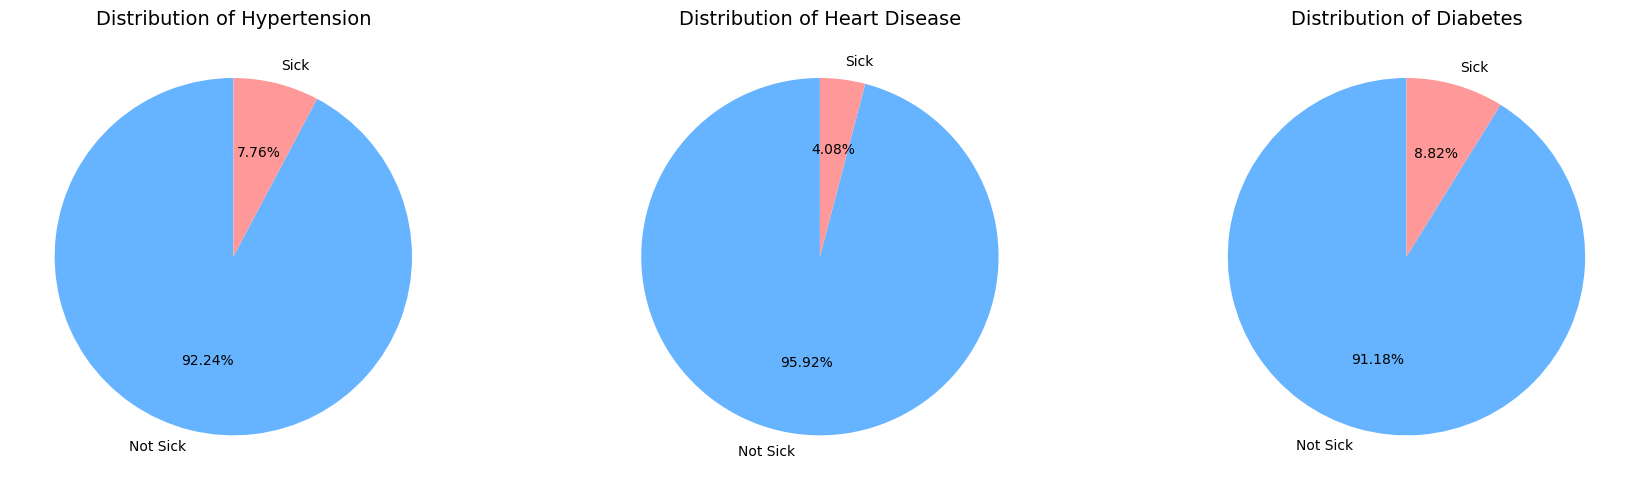

In [42]:
columns_to_plot = ['hypertension', 'heart_disease', 'diabetes']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


for i, col in enumerate(columns_to_plot):

    ax = axes[i]


    data = df[col].value_counts(normalize=True)
    data.plot.pie(autopct='%1.2f%%', labels=['Not Sick', 'Sick'],
                  colors=['#66b3ff','#ff9999'], ax=ax, startangle=90)

    ax.set_title(f"Distribution of {col.replace('_', ' ').title()}", fontsize=14)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

There are how many positive and negative cases.

Define diabets - target value

In [43]:
from sklearn.model_selection import train_test_split

X = df.drop('diabetes', axis=1)
y = df['diabetes']


# use stratify=y for save balance classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)



🌟 Exercise 2 : Model Picking and Standardization

---

Which classification model should we use for this problem, and why?

* I will use the **logistic regression model**. It is a classic, fast and robust model for binary classification problems.


Do we need to standardize the data? If so, use StandardScaler().

* Yes, because it is a mandatory and critical step.

---

In [44]:
from sklearn.preprocessing import StandardScaler

# perform StandardScaler

columns_to_scale = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# create Scaler
scaler = StandardScaler()

# learn only on X_train and transform X_train
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])

# applay this Scaler (learned)on X_test
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [45]:
y_train.dtypes

dtype('int64')

🌟 Exercise 3 : Model Training

* We will use, the logistic regression model, Train it.

========== Logistic Regression ==========
Точность (Accuracy): 0.9586
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     26299
           1       0.86      0.63      0.73      2545

    accuracy                           0.96     28844
   macro avg       0.91      0.81      0.85     28844
weighted avg       0.96      0.96      0.96     28844



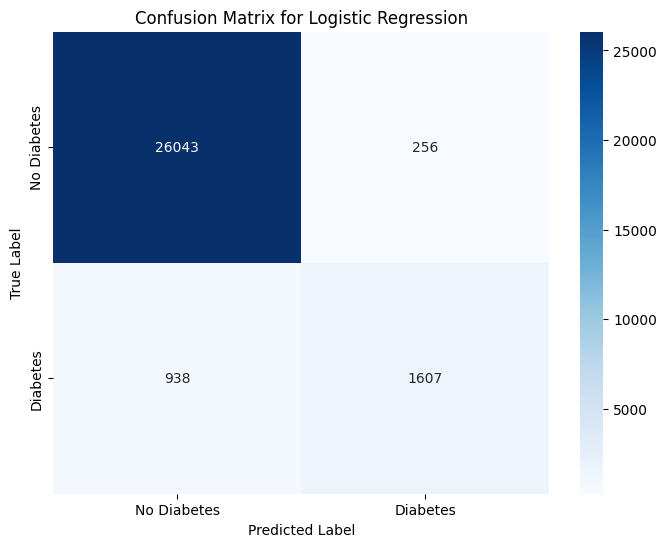



========== Decision Tree ==========
Точность (Accuracy): 0.9497
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     26299
           1       0.70      0.74      0.72      2545

    accuracy                           0.95     28844
   macro avg       0.84      0.86      0.85     28844
weighted avg       0.95      0.95      0.95     28844



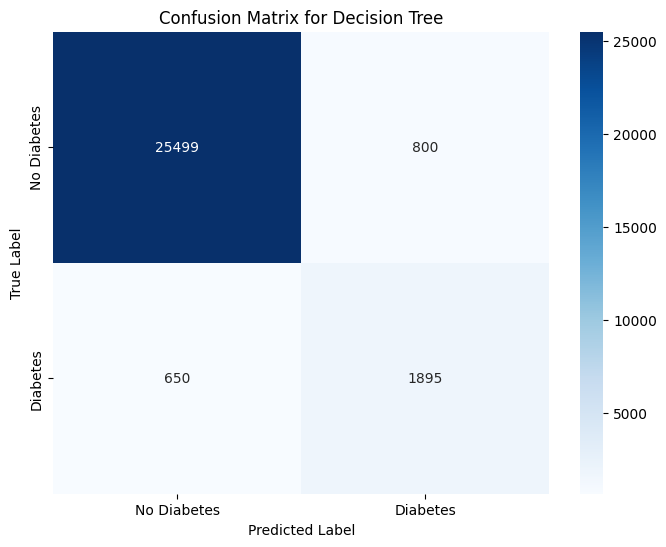



========== K-Nearest Neighbors ==========
Точность (Accuracy): 0.9601
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     26299
           1       0.89      0.63      0.73      2545

    accuracy                           0.96     28844
   macro avg       0.93      0.81      0.86     28844
weighted avg       0.96      0.96      0.96     28844



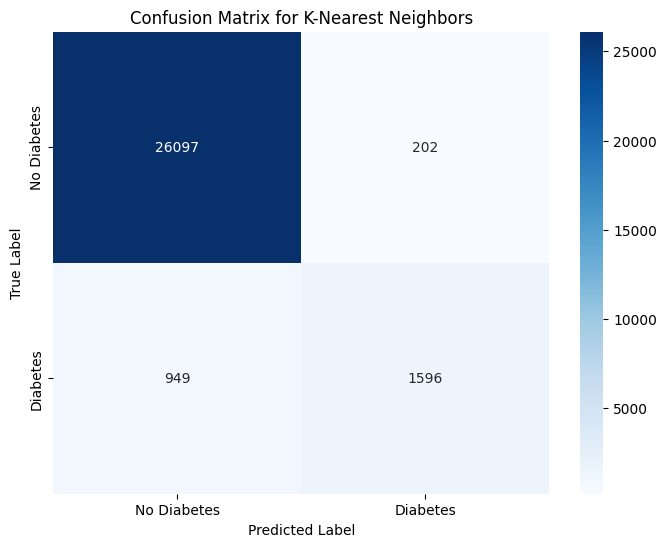



========== Random Forest ==========
Точность (Accuracy): 0.9685
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     26299
           1       0.94      0.69      0.79      2545

    accuracy                           0.97     28844
   macro avg       0.95      0.84      0.89     28844
weighted avg       0.97      0.97      0.97     28844



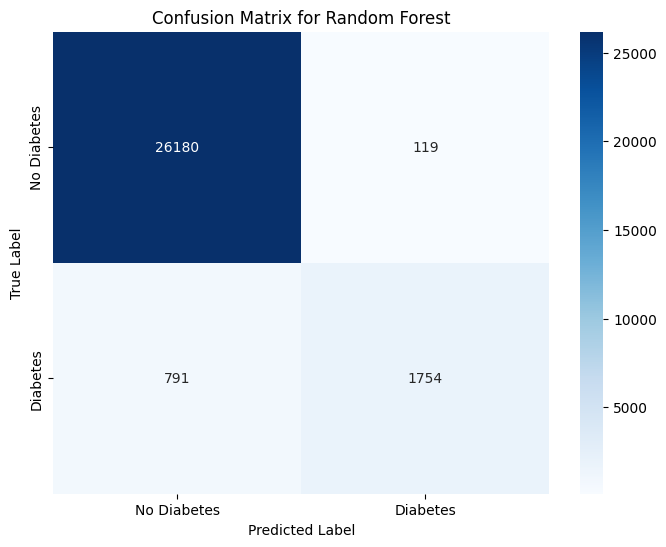

In [53]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# 1. Create dictonary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# 2. learn and score each model in a cycle
for name, model in models.items():
    # learning model
    model.fit(X_train, y_train)

    # make a prediction on test data
    y_pred = model.predict(X_test)

    # screen result
    print(f"========== {name} ==========")
    print(f"Точность (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
    print("Отчет о классификации:")
    print(classification_report(y_test, y_pred))


    # counting matrix
    cm = confusion_matrix(y_test, y_pred)

    # drow Confusion matrix(Heatmap)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

    print("\n" + "="*40 + "\n")


---

🌟 Exercise 4 : Evaluation Metrics


* Plot the accuracy score and comment the results.

---

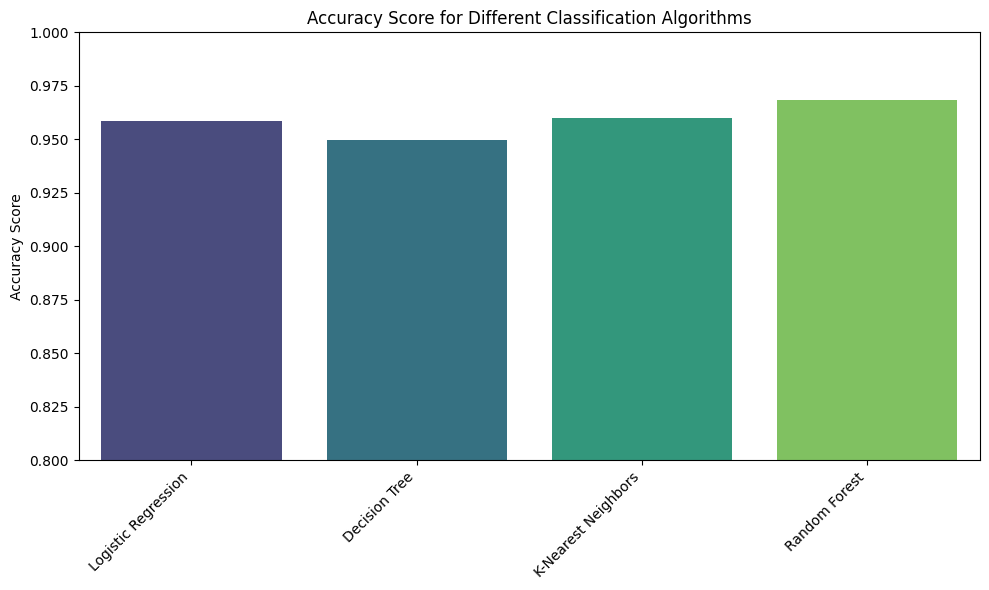


--- Accuracy Results ---
Logistic Regression: 0.9586
Decision Tree: 0.9497
K-Nearest Neighbors: 0.9601
Random Forest: 0.9685

Commentary:
The graph displays the Accuracy score for each of the tested classification models on the test dataset.
The higher the bar, the higher the model's accuracy.
By analyzing the graph, one can determine which model performed best in terms of accuracy for this diabetes prediction task.
It is also important to consider other metrics (Precision, Recall, F1-score) from the classification report for a more complete evaluation of each model's performance.


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# This code assumes you have a dictionary 'models' with your trained models,
# and also the test data X_test and y_test.

# Create empty lists to store model names and their accuracy scores
model_names = []
accuracy_scores = []

# Iterate through each trained model in the 'models' dictionary
for name, model in models.items():
    # Make predictions on the test data
    y_pred = model.predict(X_test)

    # Calculate the accuracy score
    accuracy = accuracy_score(y_test, y_pred)

    # Append the model name and its accuracy to our lists
    model_names.append(name)
    accuracy_scores.append(accuracy)

# Plot the results
plt.figure(figsize=(10, 6))

# FIX: Add hue=model_names and legend=False to remove the FutureWarning
sns.barplot(x=model_names, y=accuracy_scores, hue=model_names, palette='viridis', legend=False)

# Set the labels and title for the plot
plt.ylabel('Accuracy Score')
plt.title('Accuracy Score for Different Classification Algorithms')
plt.ylim(0.8, 1.0)  # Set y-axis limits to better visualize the differences
plt.xticks(rotation=45, ha='right')  # Rotate the x-axis labels
plt.tight_layout()  # Automatically adjust subplot params for a tight layout
plt.show()

# Print the accuracy results
print("\n--- Accuracy Results ---")
for i in range(len(model_names)):
    print(f"{model_names[i]}: {accuracy_scores[i]:.4f}")

# Add comments on the results
print("\nCommentary:")
print("The graph displays the Accuracy score for each of the tested classification models on the test dataset.")
print("The higher the bar, the higher the model's accuracy.")
print("By analyzing the graph, one can determine which model performed best in terms of accuracy for this diabetes prediction task.")
print("It is also important to consider other metrics (Precision, Recall, F1-score) from the classification report for a more complete evaluation of each model's performance.")


 ---

 * Plot the Recall, precision, F1-score and comment the results.

 ---

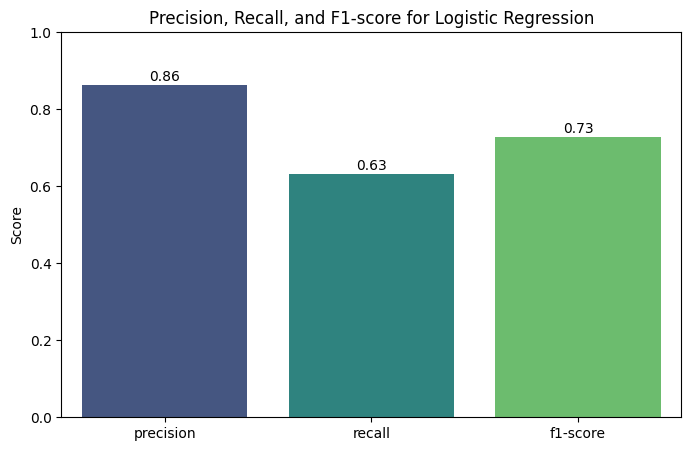

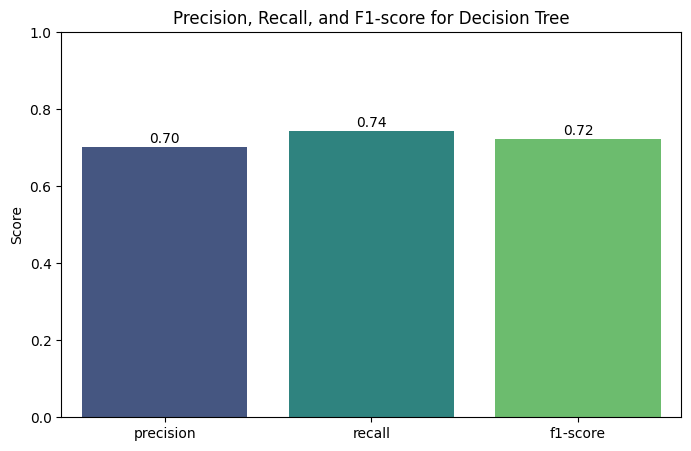

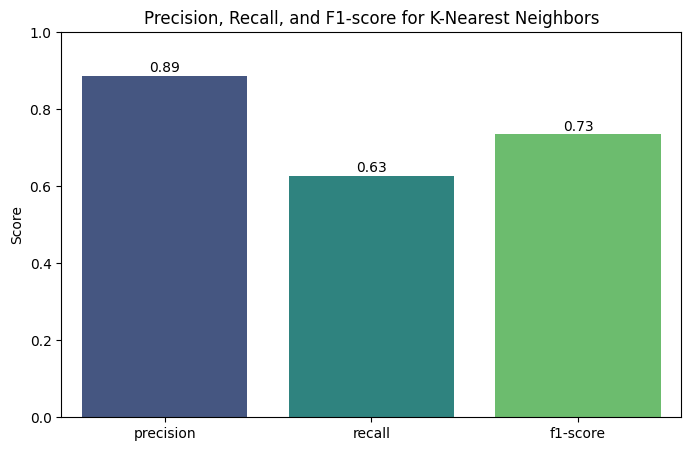

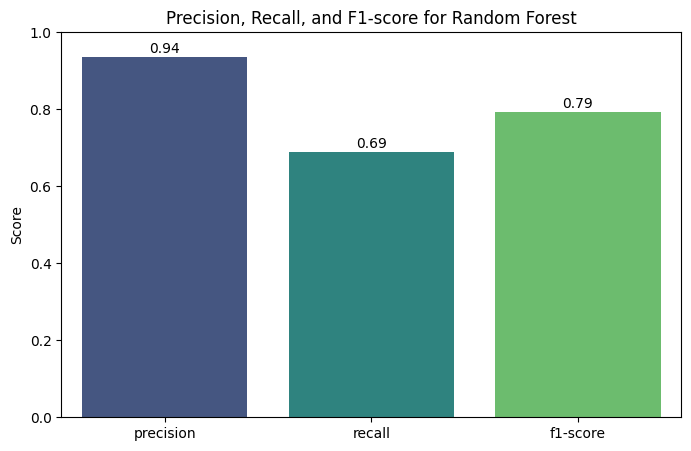

In [48]:
for name, model in models.items():
    # Generate predictions for the current model
    y_pred = model.predict(X_test)

    # Generate the classification report as a dictionary
    report = classification_report(y_test, y_pred, output_dict=True)

    # Extract metrics for the positive class ('1' represents 'Diabetes')
    # We check if '1' exists in the report to avoid errors if the model predicts only one class
    if '1' in report:
        positive_class_metrics = report['1']
        metrics = ['precision', 'recall', 'f1-score']
        scores = [positive_class_metrics[metric] for metric in metrics]

        # Plot the bar chart
        plt.figure(figsize=(8, 5))
        sns.barplot(x=metrics, y=scores, hue=metrics, palette='viridis', legend=False)

        # Add labels and a title
        plt.title(f'Precision, Recall, and F1-score for {name}')
        plt.ylim(0, 1.0)
        plt.ylabel('Score')

        # Add the score values on top of the bars
        for i, score in enumerate(scores):
            plt.text(i, score + 0.01, f"{score:.2f}", ha='center', color='black')

        # Display the plot
        plt.show()
    else:
        print(f"Model '{name}' did not predict any positive cases (Diabetes). Cannot plot metrics.")


🌟Exercise 5 : Visualizing the performance of our model

* Visualize the decision boundary with accuracy information.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


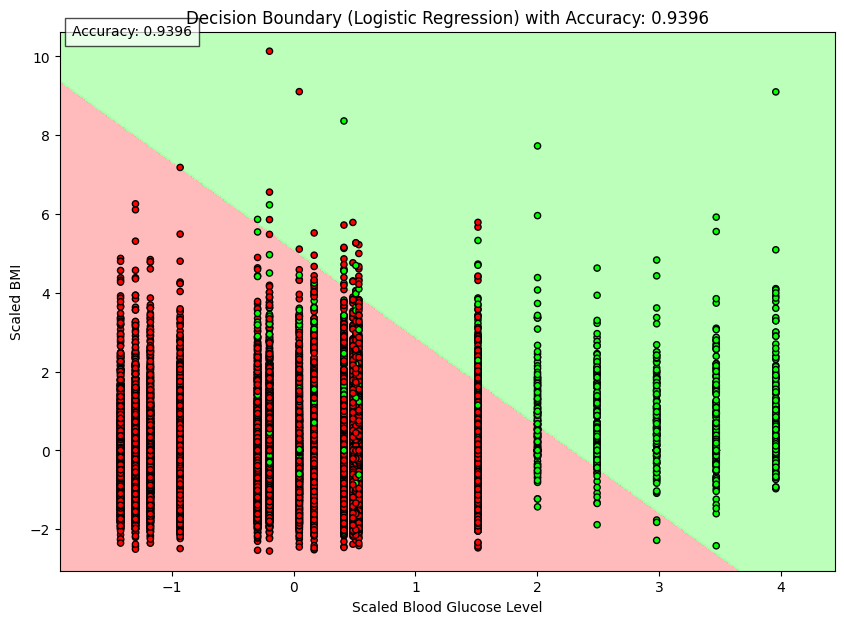

In [49]:
# prompt: create decision boundary with accuracy information(blood_glucose_level and bmi)

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# train a simple model again just on the two chosen features
model = LogisticRegression(max_iter=1000)

# Select only 'blood_glucose_level' and 'bmi' for visualization
X_train_subset = X_train[['blood_glucose_level', 'bmi']]
X_test_subset = X_test[['blood_glucose_level', 'bmi']]

# Train the model on the subset of scaled training data
model.fit(X_train_subset, y_train)

# Predict on the subset of scaled test data
y_pred_subset = model.predict(X_test_subset)

# Calculate accuracy on the subset (for display on the plot)
subset_accuracy = accuracy_score(y_test, y_pred_subset)

# Visualize the decision boundary
# Create a meshgrid of points to plot the decision boundary
x_min, x_max = X_test_subset.iloc[:, 0].min() - 0.5, X_test_subset.iloc[:, 0].max() + 0.5
y_min, y_max = X_test_subset.iloc[:, 1].min() - 0.5, X_test_subset.iloc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict the class for each point in the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00']) # Red for class 0, Green for class 1

plt.figure(figsize=(10, 7))

# Plot the decision boundary
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

# Plot also the training points (optional, can use test points too)
# We'll plot the test points to see how they fall around the boundary
plt.scatter(X_test_subset.iloc[:, 0], X_test_subset.iloc[:, 1], c=y_test, cmap=cmap_bold, s=20, edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel('Scaled Blood Glucose Level')
plt.ylabel('Scaled BMI')
plt.title(f'Decision Boundary (Logistic Regression) with Accuracy: {subset_accuracy:.4f}')

# Add accuracy information as text on the plot
plt.text(xx.min() + 0.1, yy.max() - 0.1, f'Accuracy: {subset_accuracy:.4f}',
         bbox={'facecolor': 'white', 'alpha': 0.7, 'pad': 5})

plt.show()


🌟 Exercise 6 : ROC Curve
* Plot the ROC Curve using this code template available on this link

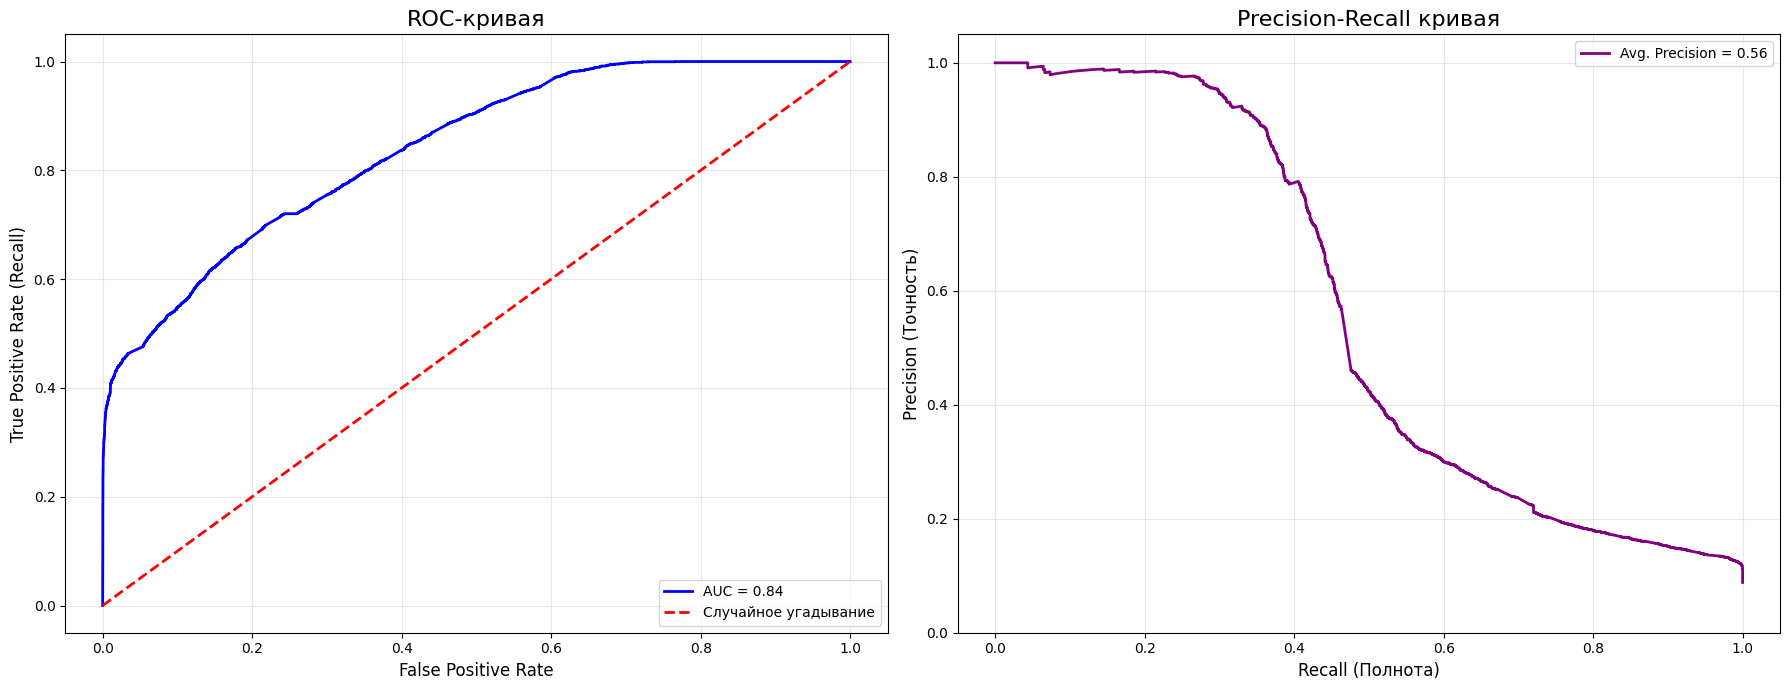

In [51]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Use the subset of X_test that the 'model' was trained on
# The 'model' in the previous cell was trained only on 'blood_glucose_level' and 'bmi' from the test set.
y_pred_proba = model.predict_proba(X_test_subset)[:, 1] # Use X_test_subset instead of X_test

# 2. counting metrix for roc
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# 3. counting metrix for Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

# 4. create charm
plt.figure(figsize=(18, 7))

#  ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Случайное угадывание')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC-кривая', fontsize=16)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Precision-Recall
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='purple', lw=2, label=f'Avg. Precision = {avg_precision:.2f}')
plt.xlabel('Recall (Полнота)', fontsize=12)
plt.ylabel('Precision (Точность)', fontsize=12)
plt.title('Precision-Recall кривая', fontsize=16)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.ylim([0.0, 1.05])

plt.tight_layout()
plt.show()